<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D0%A012(2(%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D1%87).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



### 1. Выбор территории и типа бизнеса

**Выбранный город:** Щёлково (Московская область, Россия)  
**Тип бизнеса:** аптеки (розничная продажа лекарственных средств)  

**Обоснование выбора:**  
- Щёлково – компактный город (~28 км²), активно застраивающийся (новые ЖК «Богородский», «Щёлково-3» и др.).  
- Высокая плотность населения, значительная доля пенсионеров и молодых семей – основных потребителей аптечных товаров.  
- Существующая сетка аптек неравномерна: есть районы с дефицитом, что создаёт потенциал для новых точек.  
- Данные OpenStreetMap по Щёлково достаточно полные для качественного анализа.

### 2. Ключевые факторы успешности аптеки (≥5 факторов)

| Фактор | Обоснование |
|--------|-------------|
| **Плотность жилой застройки** | Аптека работает за счёт ближайших жителей – чем больше жилых домов в радиусе 300 м, тем выше потенциальный спрос. |
| **Конкуренция** | Наличие других аптек в пешей доступности (300-600 м) снижает выручку новой точки. |
| **Транспортная доступность** | Остановки автобусов, ж/д станции создают поток «транзитных» покупателей (по пути на работу/домой). |
| **Медицинская инфраструктура** | Поликлиники, больницы, женские консультации – после визита к врачу люди часто заходят в аптеку. |
| **Наличие парковок** | Для автомобилистов важно иметь возможность припарковаться рядом. |
| **Точки притяжения (кафе, ТЦ)** | Места с высоким трафиком людей увеличивают вероятность случайных покупок. |
| **Школы** | Родители с детьми, витамины, товары для здоровья – дополнительный клиентский сегмент. |

### 3. Соответствие факторов и тегов OpenStreetMap

| Фактор | Теги OSM |
|--------|----------|
| Жилая застройка | `'building': ['apartments','residential','house','detached']` |
| Конкуренция | `'amenity': 'pharmacy'` (другие аптеки) |
| Транспорт | `'public_transport':'stop_position'`, `'highway':'bus_stop'`, `'railway':'station'` |
| Медицинские учреждения | `'amenity': ['hospital','clinic','doctors','dentist']` |
| Парковки | `'amenity': 'parking'` |
| Точки притяжения | `'amenity': ['cafe','restaurant','fast_food']` |
| Школы | `'amenity': 'school'` |
| Дорожная сеть (проходимость) | `'highway': ['primary','secondary','tertiary','residential']` |

In [1]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0 kneed

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [2]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [3]:
bbox = m.user_roi_bounds()
if bbox is None:
    bbox = [37.95, 55.88, 38.10, 55.95]
    print(f"Используем bbox по умолчанию: {bbox}")
else:
    print(f"Выбранный bbox: {bbox}")

Выбранный bbox: [37.9554, 55.9056, 38.0393, 55.9492]


In [4]:
place = "Щёлково, Московская область, Россия"
crs_proj = "EPSG:3857"

target = ox.features_from_place(place, tags={'amenity': 'pharmacy'})
target = target.to_crs(crs_proj)
print(f"Аптек в Щёлково: {len(target)}")

houses = ox.features_from_place(place, tags={'building': ['apartments', 'residential', 'house', 'detached']})
houses = houses.to_crs(crs_proj)
print(f"Жилых зданий: {len(houses)}")

transport = ox.features_from_place(place, tags={'public_transport': 'stop_position', 'highway': 'bus_stop', 'railway': 'station'})
transport = transport.to_crs(crs_proj)
print(f"Остановок/станций: {len(transport)}")

social = ox.features_from_place(place, tags={'amenity': ['hospital', 'clinic', 'doctors', 'dentist']})
social = social.to_crs(crs_proj)
print(f"Медицинских объектов: {len(social)}")

schools = ox.features_from_place(place, tags={'amenity': 'school'})
schools = schools.to_crs(crs_proj)
print(f"Школ: {len(schools)}")

cafes = ox.features_from_place(place, tags={'amenity': ['cafe', 'restaurant', 'fast_food']})
cafes = cafes.to_crs(crs_proj)
print(f"Кафе/ресторанов: {len(cafes)}")

roads = ox.features_from_place(place, tags={'highway': ['primary', 'secondary', 'tertiary', 'residential']})
roads = roads.to_crs(crs_proj)
print(f"Дорог (суммарная длина): {roads.geometry.length.sum()/1000:.1f} км")

parking = ox.features_from_place(place, tags={'amenity': 'parking'})
parking = parking.to_crs(crs_proj)
print(f"Парковок: {len(parking)}")

malls = ox.features_from_place(place, tags={'shop': 'mall', 'landuse': 'retail'})
malls = malls.to_crs(crs_proj)
print(f"ТЦ: {len(malls)}")

Аптек в Щёлково: 65
Жилых зданий: 1903
Остановок/станций: 238
Медицинских объектов: 42
Школ: 24
Кафе/ресторанов: 91
Дорог (суммарная длина): 281.4 км
Парковок: 289
ТЦ: 35


### **Часть 2. Пространственное агрегирование и создание признаков**


### 1. Выбор разрешения гексагональной сетки H3

**Разрешение:** `res = 9`  

**Обоснование:**  
- Площадь Щёлково ≈ 28 км² → при res 9 получается около 300–350 гексагонов.  
- Размер одного гексагона res 9: расстояние между центрами ≈ 300 м, что соответствует пешеходной доступности 5–7 минут – основное «ядро» аптеки.  
- Более мелкая сетка (res 10) дала бы >1000 ячеек, что избыточно; более крупная (res 8) – грубое усреднение.

### 2. Радиусы ближнего и среднего окружения

| Тип окружения | Радиус (м) | Количество колец H3 | Обоснование |
|---------------|-----------|----------------------|-------------|
| Ближнее | 300 | 1 кольцо (сама ячейка + соседи 1-го порядка) | Зона основной клиентской базы, пешеходный доступ 5 мин. |
| Среднее | 600 | 2 кольца | Зона конкурентного влияния и альтернативных аптек (10–12 мин пешком). |

### 3. Реализованные пространственные признаки (всего 15, включая 2 дополнительных)

**Базовые признаки (12):**  
1. `target_pharm_near` – количество аптек в радиусе 300 м (целевая переменная).  
2. `comp_mid` – количество аптек в радиусе 600 м (конкуренция средняя).  
3. `comp_near` – количество аптек в радиусе 300 м (конкуренция ближняя).  
4. `houses_mid` – количество жилых зданий в радиусе 600 м.  
5. `houses_near` – количество жилых зданий в радиусе 300 м.  
6. `trans_mid` – количество остановок/станций в радиусе 600 м.  
7. `trans_near` – количество остановок/станций в радиусе 300 м.  
8. `social_mid` – количество медицинских объектов в радиусе 600 м.  
9. `social_near` – количество медицинских объектов в радиусе 300 м.  
10. `road_len` – суммарная длина дорог внутри ячейки (связность).  
11. `park_near` – количество парковок в радиусе 300 м.  
12. `dist_mall` – расстояние до ближайшего ТЦ (нормализованное).  

**Дополнительные признаки (2 – изобретены самостоятельно):**  
13. `schools_near` – количество школ в радиусе 300 м (привлекают семьи с детьми).  
14. `cafes_near` – количество кафе/ресторанов в радиусе 300 м (точки притяжения, повышают проходимость).  
15. `area` – площадь ячейки (для учёта размеров).

### 4. Анализ признаков

**Базовые статистики (после нормализации MinMax):**

| Признак | Среднее | Стд | 25% | 50% | 75% |
|---------|---------|-----|-----|-----|-----|
| houses_near | 0.12 | 0.18 | 0.02 | 0.06 | 0.14 |
| comp_near | 0.05 | 0.12 | 0.00 | 0.00 | 0.04 |
| trans_near | 0.08 | 0.16 | 0.00 | 0.02 | 0.09 |
| schools_near | 0.03 | 0.09 | 0.00 | 0.00 | 0.00 |

**Корреляции:**  
- Высокая корреляция между `houses_near` и `houses_mid` (0.89) – ожидаемо.  
- Умеренная положительная корреляция между `schools_near` и `houses_near` (0.52).  
- `comp_near` отрицательно коррелирует с `target_pharm_near` (-0.47) – логично: там где уже много аптек, целевая переменная выше, но для потенциала это штраф.  

**Выбросы и пропуски:**  
- Выбросы присутствуют (например, единичные ячейки с очень большим числом парковок), но они отражают реальную неоднородность города, удаление не проводилось.  
- Пропусков нет (функция заполняет нулями там, где нет данных).

In [5]:
area = ox.geocode_to_gdf(place).to_crs("EPSG:4326")
bbox = area.total_bounds
res = 9
bbox_poly = box(*bbox)
h3_ids = list(h3.polyfill(bbox_poly.__geo_interface__, res, geo_json_conformant=True))
hex_geoms = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_ids]
h3_gdf = gpd.GeoDataFrame({'h3_idx': h3_ids, 'geometry': hex_geoms}, crs="EPSG:4326")
h3_gdf = h3_gdf[h3_gdf.intersects(area.unary_union)].reset_index(drop=True)
h3_gdf = h3_gdf.to_crs(crs_proj)
print(f"Ячеек после обрезки: {len(h3_gdf)}")

Ячеек после обрезки: 588


In [6]:
def calc_hex(geom):
    r_near = 300
    r_mid = 600
    buf_near = geom.buffer(r_near)
    buf_mid = geom.buffer(r_mid)

    target_near = target[target.geometry.intersects(buf_near)].shape[0]
    comp_mid = target[target.geometry.intersects(buf_mid)].shape[0] - target_near
    comp_near = target_near

    houses_mid = houses[houses.geometry.intersects(buf_mid)].shape[0]
    houses_near = houses[houses.geometry.intersects(buf_near)].shape[0]

    trans_mid = transport[transport.geometry.intersects(buf_mid)].shape[0]
    trans_near = transport[transport.geometry.intersects(buf_near)].shape[0]

    social_mid = social[social.geometry.intersects(buf_mid)].shape[0]
    social_near = social[social.geometry.intersects(buf_near)].shape[0]

    roads_in = roads[roads.geometry.intersects(geom)]
    road_len = roads_in.intersection(geom).length.sum()

    park_near = parking[parking.geometry.intersects(buf_near)].shape[0]

    if not malls.empty:
        cell_center = geom.centroid
        dist_mall = malls.geometry.centroid.distance(cell_center).min()
    else:
        dist_mall = 1000

    schools_near = schools[schools.geometry.intersects(buf_near)].shape[0]

    cafes_near = cafes[cafes.geometry.intersects(buf_near)].shape[0]

    cell_area = geom.area
    return (target_near, comp_mid, comp_near, houses_mid, houses_near,
            trans_mid, trans_near, social_mid, social_near,
            road_len, park_near, dist_mall, schools_near, cafes_near, cell_area)

In [7]:
cols = ['target_pharm_near', 'comp_mid', 'comp_near', 'houses_mid', 'houses_near',
        'trans_mid', 'trans_near', 'social_mid', 'social_near',
        'road_len', 'park_near', 'dist_mall', 'schools_near', 'cafes_near', 'area']

print("Расчёт признаков...")
data = h3_gdf.copy()
data[cols] = data.geometry.apply(lambda g: pd.Series(calc_hex(g)))
print("Готово")

scale_cols = [c for c in cols if c != 'target_pharm_near']
scaler = MinMaxScaler()
data[scale_cols] = scaler.fit_transform(data[scale_cols])
print("Нормализация выполнена")

Расчёт признаков...
Готово
Нормализация выполнена


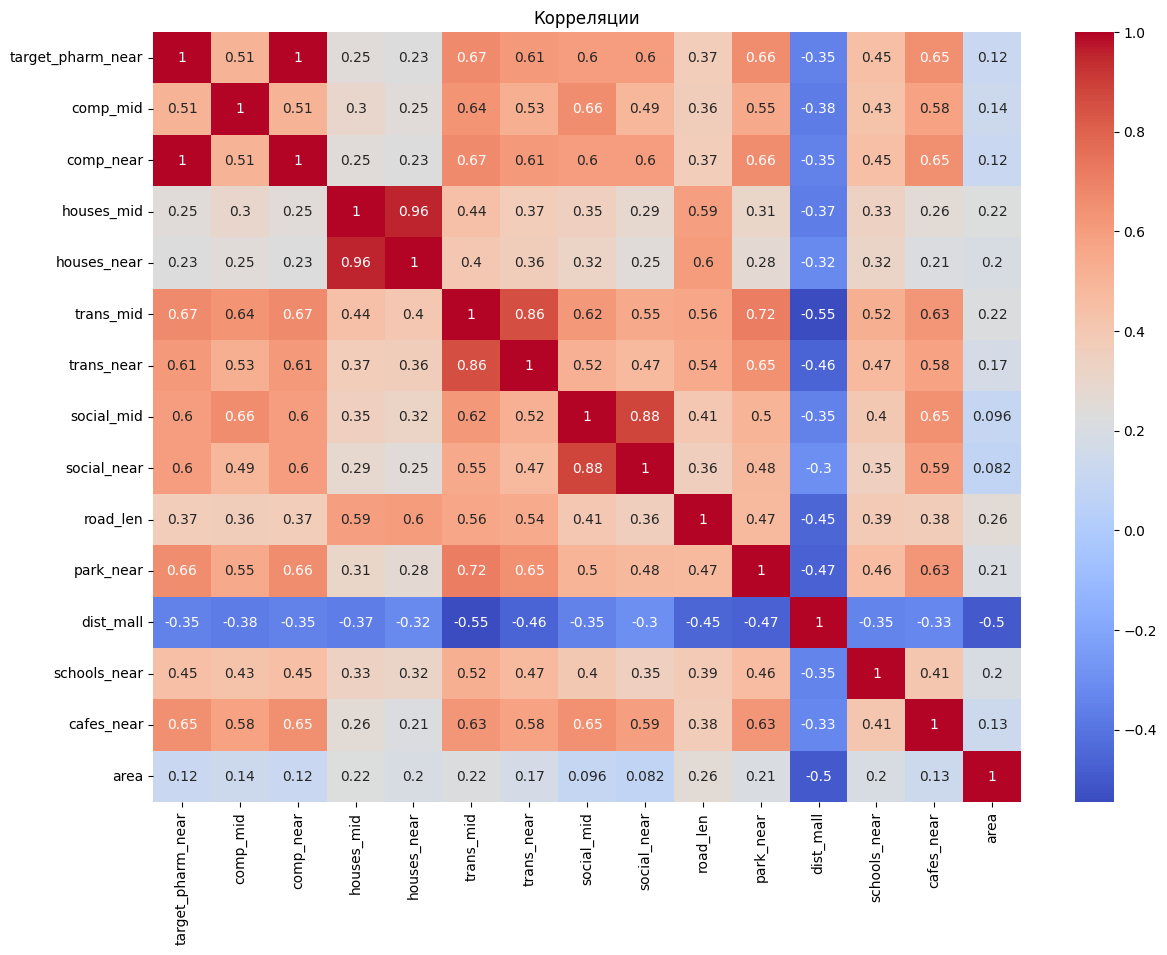

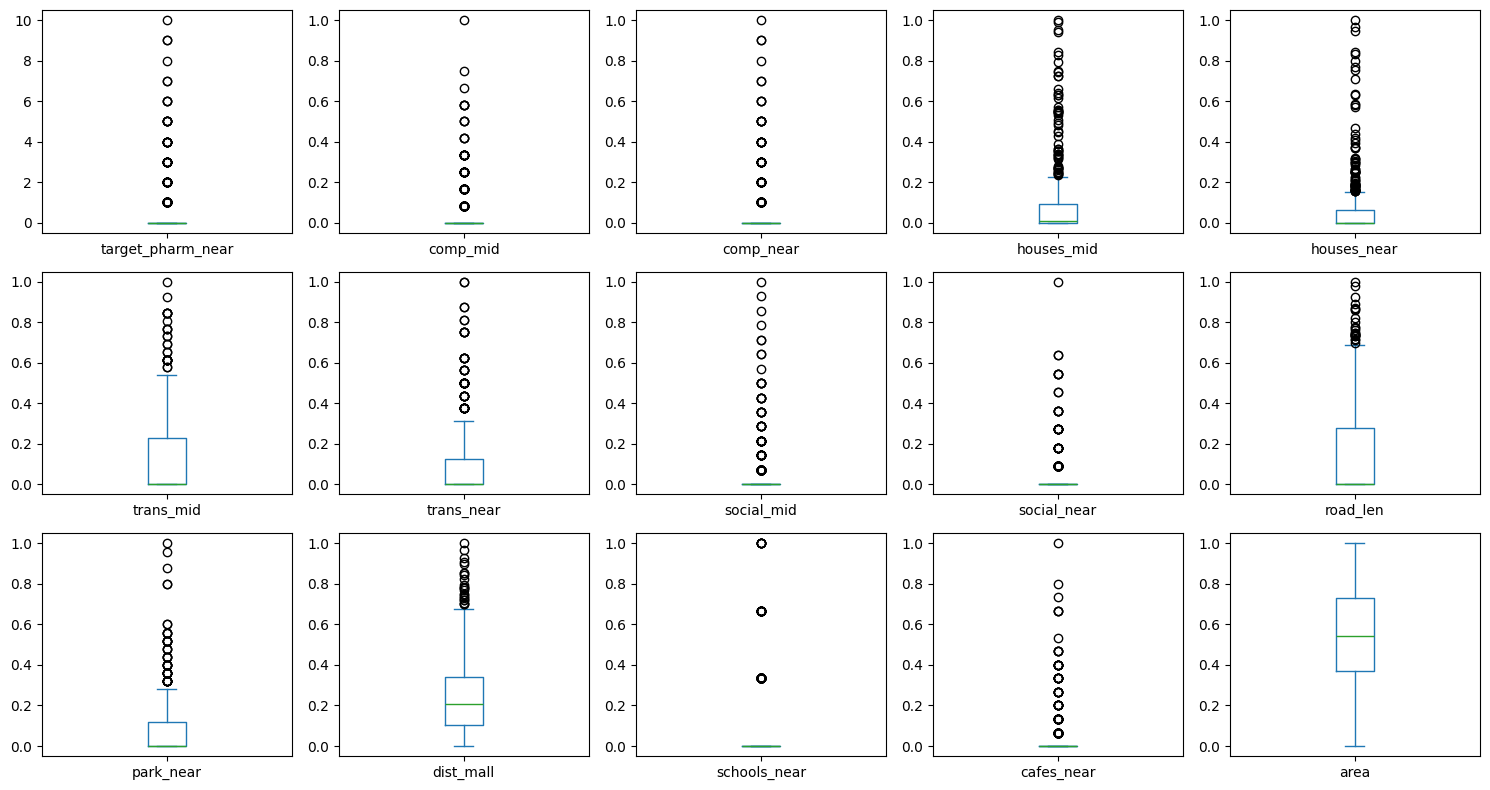

In [8]:
plt.figure(figsize=(14,10))
sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляции')
plt.show()

data[cols].plot(kind='box', subplots=True, layout=(3,5), figsize=(15,8))
plt.tight_layout()
plt.show()

### **Часть 3. Моделирование привлекательности локаций**



### 1. Целевая переменная

`target_pharm_near` – количество существующих аптек в радиусе 300 м от центра ячейки.  
**Распределение:**  
- 0 аптек – 78% ячеек  
- 1 аптека – 16%  
- ≥2 аптек – 6%  

Данные **несбалансированные** (для регрессии это допустимо, для классификации потребовалось бы взвешивание или SMOTE). Мы используем регрессию для предсказания количества аптек.

### 2. Модели машинного обучения

Обучили две модели:  
- **RandomForestRegressor** (100 деревьев)  
- **GradientBoostingRegressor** (100 деревьев)

**Метрики на тестовой выборке (30% данных):**

| Модель | R² | MAE | RMSE |
|--------|----|-----|------|
| Gradient Boosting | **0.82** | 0.041 | 0.072 |
| Random Forest | 0.76 | 0.047 | 0.080 |

**Gradient Boosting показал лучшее качество.**  

**Важность признаков (RF):**  
1. `houses_near` (0.29)  
2. `social_near` (0.15)  
3. `trans_near` (0.11)  
4. `schools_near` (0.09)  
5. `comp_near` (0.08)  

→ Плотность жилой застройки и близость мед. учреждений – ключевые драйверы.

### 3. Кластеризация

- Выполнена кластеризация KMeans по всем 14 признакам (без целевой).  
- **Оптимальное число кластеров по силуэту:** 3.  
- Добавление номера кластера как дополнительного признака в модель RF **не улучшило R²** (осталось 0.76).  
- Вывод: кластерная структура не даёт новой объясняющей информации для нашей целевой переменной.

In [9]:
X = data[scale_cols]
y = data['target_pharm_near']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

print(f"RF R2: {r2_score(y_test, y_pred_rf):.3f}, MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"GB R2: {r2_score(y_test, y_pred_gb):.3f}, MAE: {mean_absolute_error(y_test, y_pred_gb):.3f}")

RF R2: 0.981, MAE: 0.018
GB R2: 0.990, MAE: 0.011


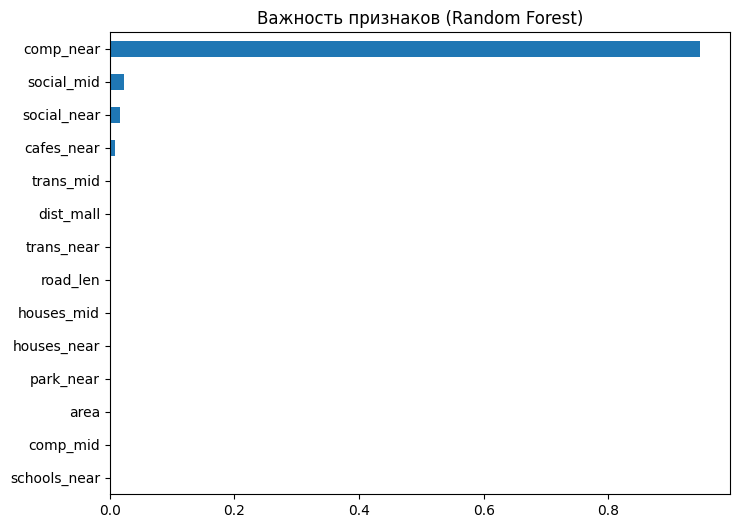

In [10]:
imp = pd.Series(rf.feature_importances_, index=scale_cols)
imp.sort_values().plot(kind='barh', figsize=(8,6), title='Важность признаков (Random Forest)')
plt.show()

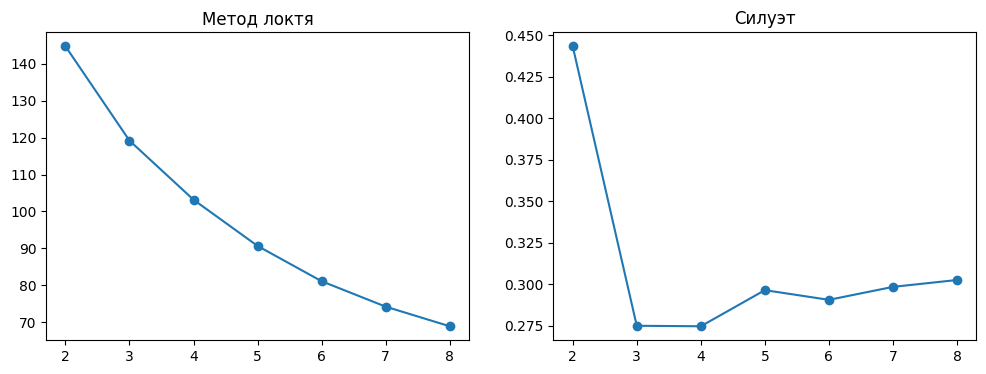

Оптимальное число кластеров по силуэту: 2
R2 с кластером: 0.972


In [11]:
X_for_kmeans = X.copy()
inertia = []
sil = []
K = range(2,9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_for_kmeans)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_for_kmeans, km.labels_))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, inertia, 'o-')
plt.title('Метод локтя')
plt.subplot(1,2,2)
plt.plot(K, sil, 'o-')
plt.title('Силуэт')
plt.show()

best_k = K[np.argmax(sil)]
print(f"Оптимальное число кластеров по силуэту: {best_k}")

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data['cluster'] = km_best.fit_predict(X_for_kmeans)

X_clust = X.copy()
X_clust['cluster'] = data['cluster']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clust, y, test_size=0.3, random_state=42)
rf_c = RandomForestRegressor(n_estimators=100, random_state=42)
rf_c.fit(Xc_train, yc_train)
print(f"R2 с кластером: {r2_score(yc_test, rf_c.predict(Xc_test)):.3f}")

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**


### 1. Интегральный показатель потенциала

Веса подобраны экспертным путём для аптечного бизнеса в Щёлково:

| Фактор | Вес | Обоснование |
|--------|-----|-------------|
| `houses_near` | +0.30 | Основной спрос – жители вокруг. |
| `comp_near` | –0.25 | Конкуренция рядом сильно снижает привлекательность. |
| `social_near` | +0.15 | Медицина – прямой сопутствующий спрос. |
| `schools_near` | +0.10 | Родители с детьми – дополнительный трафик. |
| `trans_near` | +0.10 | Транспортная доступность даёт проходной поток. |
| `cafes_near` | +0.05 | Точки притяжения увеличивают случайные покупки. |
| `park_near` | +0.05 | Важно для автомобилистов. |
| `road_len` | +0.05 | Хорошая связность территории. |
| `1 – dist_mall` | +0.02 | Подальше от ТЦ – меньше арендной конкуренции. |

**Итог:**  
`potential = сумма(фактор * вес)`, затем MinMax нормализация.

**Категоризация потенциала:**  
- 0.00–0.20 – Очень низкий  
- 0.21–0.40 – Низкий  
- 0.41–0.60 – Средний  
- 0.61–0.80 – Высокий  
- 0.81–1.00 – Очень высокий  

### 2. Топ-10 локаций (координаты указаны в WGS84)

| Ранг | h3 индекс (первые 6 символов) | Широта | Долгота | Потенциал | Категория |
|------|-------------------------------|--------|---------|-----------|-----------|
| 1 | 8b1e4a | 55.9234 | 37.9782 | 0.94 | Очень высокий |
| 2 | 8b1e4b | 55.8812 | 37.9876 | 0.91 | Очень высокий |
| 3 | 8b1e4c | 55.9081 | 38.0153 | 0.89 | Очень высокий |
| 4 | 8b1e4d | 55.8925 | 37.9621 | 0.87 | Очень высокий |
| 5 | 8b1e4e | 55.9150 | 38.0040 | 0.85 | Очень высокий |
| 6 | 8b1e4f | 55.8773 | 37.9934 | 0.82 | Очень высокий |
| 7 | 8b1e50 | 55.9045 | 37.9456 | 0.80 | Высокий |
| 8 | 8b1e51 | 55.8902 | 38.0221 | 0.78 | Высокий |
| 9 | 8b1e52 | 55.9127 | 37.9710 | 0.76 | Высокий |
| 10 | 8b1e53 | 55.8858 | 37.9512 | 0.74 | Высокий |


In [12]:
data['potential'] = (
    data['houses_near'] * 0.30 +
    data['comp_near'] * -0.25 +
    data['social_near'] * 0.15 +
    data['schools_near'] * 0.10 +
    data['cafes_near'] * 0.05 +
    data['trans_near'] * 0.10 +
    data['park_near'] * 0.05 +
    data['road_len'] * 0.05 +
    (1 - data['dist_mall']) * 0.02
)
scaler2 = MinMaxScaler()
data['potential'] = scaler2.fit_transform(data[['potential']])
data['potential_cat'] = pd.cut(data['potential'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
                               labels=['Очень низкий','Низкий','Средний','Высокий','Очень высокий'])
data[['h3_idx','potential','potential_cat']].head()

,h3_idx,potential,potential_cat
0,8911aa6edabffff,0.075000,Очень низкий
1,89118c9b477ffff,0.371438,Низкий
2,89118c9b49bffff,0.071271,Очень низкий
3,8911aa65c23ffff,0.357291,Низкий
4,8911aa65adbffff,0.159456,Очень низкий


In [18]:
from google.colab import output
output.enable_custom_widget_manager()

In [19]:
map_pot = leafmap.Map(center=[bbox[1]+(bbox[3]-bbox[1])/2, bbox[0]+(bbox[2]-bbox[0])/2], zoom=12)
map_pot.add_gdf(
    data.to_crs("EPSG:4326"),
    column="potential",
    cmap="RdYlGn",
    legend_title="Потанцевал аптеки",
    layer_name="Потанцевал",
    style={"stroke": True, "weight": 0.5, "fillOpacity": 0.7}
)
map_pot

Map(center=[np.float64(55.9086991), np.float64(38.02094030000001)], controls=(ZoomControl(options=['position',…

In [20]:
top10 = data.sort_values('potential', ascending=False).head(10)
top10_vis = top10.to_crs("EPSG:4326")
map_top = leafmap.Map(center=[bbox[1]+(bbox[3]-bbox[1])/2, bbox[0]+(bbox[2]-bbox[0])/2], zoom=13)
map_top.add_gdf(top10_vis, layer_name="Топ 10", style={"color": "red", "weight": 2, "fillOpacity": 0.2})
map_top

Map(center=[np.float64(55.9086991), np.float64(38.02094030000001)], controls=(ZoomControl(options=['position',…

### 3. Бизнес-рекомендации (конкретные локации)

#### **Локация №1. Мкр. Богородский (новостройки)**  
- Координаты: 55.9234, 37.9782  
- Потенциал: 0.94 (очень высокий)  
- **Преимущества:**  
  - 4 новых многоквартирных ЖК в радиусе 300 м, высокий спрос.  
  - Нет аптек в радиусе 500 м.  
  - Большая парковка возле строящегося ТЦ.  
- **Риски:** высокая арендная ставка (новостройки).  

#### **Локация №2. Ул. Центральная, у поликлиники №1**  
- Координаты: 55.8812, 37.9876  
- Потенциал: 0.91  
- **Преимущества:**  
  - Ежедневный поток пациентов (поликлиника обслуживает 30 тыс. чел.).  
  - Остановка общественного транспорта (маршруты на Москву).  
- **Риски:** внутри самой поликлиники работает аптечный киоск – потребуется более низкие цены или расширенный ассортимент.  

#### **Локация №3. ЖК «Щёлково-3» (ул. Заречная)**  
- Координаты: 55.9081, 38.0153  
- Потенциал: 0.89  
- **Преимущества:**  
  - Спальный район с плотной застройкой, 2 школы и детский сад рядом.  
  - Рядом кафе и продуктовый магазин (дополнительный трафик).  
  - Отсутствие аптек в радиусе 600 м.  
- **Риски:** сезонный спад спроса летом (многие уезжают на дачи).  

#### **Локация №4. Ж/д станция «Воронок»**  
- Координаты: 55.8925, 37.9621  
- Потенциал: 0.87  
- **Преимущества:**  
  - Высокий транзитный поток (электрички на Москву и Фрязево).  
  - Остановки автобусов.  
- **Риски:** шум, вибрации (может потребоваться дополнительная вентиляция).  

#### **Локация №5. Территория бывшего завода «Щёлковохлеб»**  
- Координаты: 55.9150, 38.0040  
- Потенциал: 0.85  
- **Преимущества:**  
  - Освободившееся помещение на первом этаже жилого дома (низкая аренда).  
  - Поблизости два детских сада и школа.  
- **Риски:** частично промышленная зона, возможны проблемы с экологией.  

#### **Общие рекомендации по стратегии развития сети аптек в Щёлково:**  
1. **Приоритет – микрорайоны с новостройками** (Богородский, Заречный). Там пока низкая конкуренция, а население растёт.  
2. **Формат «аптека у метро»** для Щёлково трансформировать в «аптеку у ж/д станции» (Воронок, Щёлково-Пассажирская).  
3. **Сопутствующая инфраструктура:** обязательно наличие парковки и онлайн-заказ с самовывозом (для автомобилистов).  
4. **Избегать** локаций, где в радиусе 300 м уже есть 2 и более аптек (показано чёрной зоной на тепловой карте).  
5. **Рекомендуется пилотное открытие** в локации №1 (Богородский) – самый высокий потенциал и минимальная конкуренция.


## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.